<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_005_clustering/05_Mezclas_Gaussianas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering de Mezclas Gaussianas (GMM, Gaussian Mixture Models)

El Clustering de Mezclas Gaussianas (GMM, Gaussian Mixture Models) es una técnica probabilística de agrupamiento basada en el supuesto de que los datos provienen de una combinación (mezcla) de varias distribuciones gaussianas (también llamadas normales).

A diferencia de k-means, que asigna cada punto a un único clúster de manera determinista, GMM permite una asignación probabilística: cada punto tiene una probabilidad de pertenecer a cada clúster.

## Eduardo Zurek, Ph.D.
Inteligencia Artificial

Ingeniería de Sistemas

Universidad del Norte

## Fundamentos

### Fundamentos de Gaussian Mixture Models (GMM)

1. **Modelo de mezcla**  
   Se asume que los datos $X = \{x_1, x_2, \ldots, x_n\}$ provienen de una combinación de $k$ distribuciones gaussianas:

   $$
   p(x) = \sum_{j=1}^{k} \pi_j \, \mathcal{N}(x \mid \mu_j, \Sigma_j)
   $$

   donde:
   - $\pi_j$: peso de la mezcla (proporción del clúster $j$), con $\sum_j \pi_j = 1$.
   - $\mu_j$: vector de medias del clúster $j$.
   - $\Sigma_j$: matriz de covarianza del clúster $j$.
   - $\mathcal{N}(x \mid \mu_j, \Sigma_j)$: densidad de una gaussiana multivariada.

---

2. **Estimación de parámetros**  
   Los parámetros $(\pi_j, \mu_j, \Sigma_j)$ se estiman con el algoritmo **Expectation-Maximization (EM):**

   - **E-step (Expectation):** calcular las responsabilidades o probabilidades de pertenencia de cada punto $x_i$ a cada clúster $j$:

     $$
     \gamma_{ij} = \frac{\pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}{\sum_{l=1}^k \pi_l \, \mathcal{N}(x_i \mid \mu_l, \Sigma_l)}
     $$

   - **M-step (Maximization):** actualizar los parámetros usando esas probabilidades.

---

3. **Asignación final de clúster**  
   - Se puede asignar cada punto al clúster con **probabilidad máxima**:

     $$
     \hat{z_i} = \arg\max_j \gamma_{ij}
     $$

   - O mantener las probabilidades $\gamma_{ij}$ si interesa modelar la **incertidumbre**.

---


### Ventajas y Desventajas
#### Ventajas

Permite clústeres de forma elíptica, no solo esféricos (a diferencia de k-means).

Cada clúster tiene su propia matriz de covarianza, lo que lo hace más flexible.

Brinda probabilidades de pertenencia, útiles en contextos con incertidumbre.

#### Desventajas

Requiere elegir el número de componentes $k$.

Puede converger a un mínimo local (sensible a inicialización).

Computacionalmente más costoso que k-means.

## Selección de $k$ (número de gaussianas)

### AIC – Akaike Information Criterion

El **AIC** busca un equilibrio entre:

- **Bondad de ajuste del modelo** (qué tan bien explica los datos).  
- **Complejidad del modelo** (número de parámetros).

La fórmula es:

$$
\text{AIC} = 2k - 2 \ln(L)
$$

donde:  
- $k$: número de parámetros del modelo.  
- $L$: valor de la verosimilitud máxima.  

👉 El mejor modelo es el que tenga el **AIC más pequeño**.  


---

### BIC – Bayesian Information Criterion

El **BIC** también balancea ajuste y complejidad, pero penaliza más fuerte cuando hay muchos datos:

$$
\text{BIC} = \ln(n) \, k - 2 \ln(L)
$$

donde:  
- $n$: número de observaciones.  
- $k$: número de parámetros.  
- $L$: verosimilitud máxima.  

👉 El mejor modelo es el que tenga el **BIC más pequeño**.  


---

### Diferencias clave entre AIC y BIC

| Criterio | Penalización | Tendencia |
|----------|--------------|-----------|
| **AIC** | $2k$ | Prefiere modelos más complejos (más clústeres). |
| **BIC** | $\ln(n) \cdot k$ | Prefiere modelos más simples, sobre todo cuando $n$ es grande. |

- Con **pocos datos**, AIC y BIC suelen coincidir.  
- Con **muchos datos**, BIC es más conservador que AIC.  

---


### Verosimilitud

En estadística, la **verosimilitud** mide **qué tan probable es observar los datos** $X = \{x_1, x_2, ..., x_n\}$ dados unos parámetros $\theta$ de un modelo.  

Se define como:

$$
L(\theta \mid X) = \prod_{i=1}^n p(x_i \mid \theta)
$$

donde:
- $p(x_i \mid \theta)$ es la probabilidad (o densidad, si es continuo) de observar $x_i$ bajo el modelo parametrizado por $\theta$.
  
- El producto se debe a que asumimos independencia entre las observaciones.  

👉 La verosimilitud responde: *“Si el modelo tiene parámetros $\theta$, ¿qué tan probable es haber obtenido estos datos?”*


---

### Verosimilitud máxima (MLE: *Maximum Likelihood Estimation*)

La **verosimilitud máxima** corresponde a elegir los parámetros $\theta$ que hacen que los datos observados sean lo más probables posible:  

$$
\hat{\theta}_{MLE} = \arg\max_{\theta} L(\theta \mid X)
$$

En la práctica se usa el **logaritmo de la verosimilitud** (*log-likelihood*), ya que convierte productos en sumas:

$$
\ell(\theta \mid X) = \ln L(\theta \mid X) = \sum_{i=1}^n \ln p(x_i \mid \theta)
$$

El máximo de $L(\theta)$ y de $\ell(\theta)$ ocurre en el mismo punto.


---

### Ejemplo simple

Supongamos que los datos son $X = \{2, 3, 2, 4\}$, y que creemos que provienen de una distribución **normal** con media $\mu$ y varianza $\sigma^2$.

La verosimilitud es:

$$
L(\mu, \sigma^2 \mid X) = \prod_{i=1}^4 \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)
$$

El MLE busca los valores de $\mu$ y $\sigma^2$ que maximizan esta expresión.  

👉 El resultado es:  
- $\hat{\mu} =$ **media muestral**.  
- $\hat{\sigma}^2 =$ **varianza muestral**.  


---

### Relación con AIC y BIC

Tanto **AIC** como **BIC** dependen del valor de la verosimilitud máxima:

- En AIC:

$$
AIC = 2k - 2\ln(L_{\text{max}})
$$

- En BIC:

$$
BIC = \ln(n) \cdot k - 2\ln(L_{\text{max}})
$$

donde $L_{\text{max}}$ es la verosimilitud evaluada en los parámetros que maximizan la probabilidad de los datos.

👉 La verosimilitud máxima mide la **calidad del ajuste** y AIC/BIC le agregan una penalización por complejidad.

---


## Ejemplo de Mezclas Gaussianas

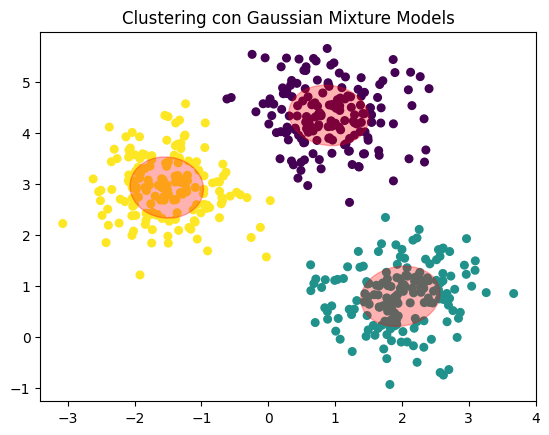

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

# Datos sintéticos
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=0)

# Ajustar GMM con 3 componentes
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0)
gmm.fit(X)
labels = gmm.predict(X)

# Visualización
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap='viridis')

# Dibujar elipses de covarianza
import matplotlib as mpl
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        orient = np.arctan2(U[1, 0], U[0, 0])
        width, height = 2 * np.sqrt(s)
    else:
        orient = 0
        width, height = 2 * np.sqrt(covariance)
    ell = mpl.patches.Ellipse(position, width, height, angle=np.degrees(orient), **kwargs)
    ax.add_patch(ell)

for pos, covar in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(pos, covar, alpha=0.3, color='red')

plt.title("Clustering con Gaussian Mixture Models")
plt.show()


## Resultados de $k$ para diferentes configuraciones de datos

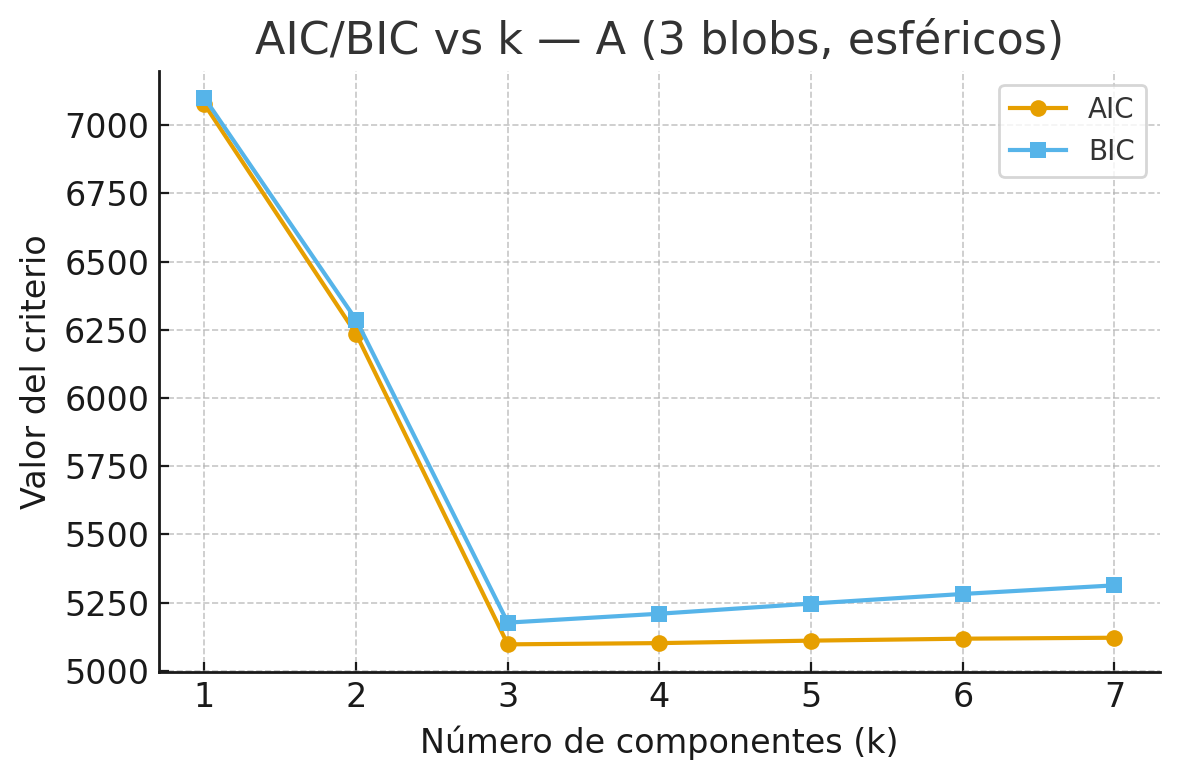

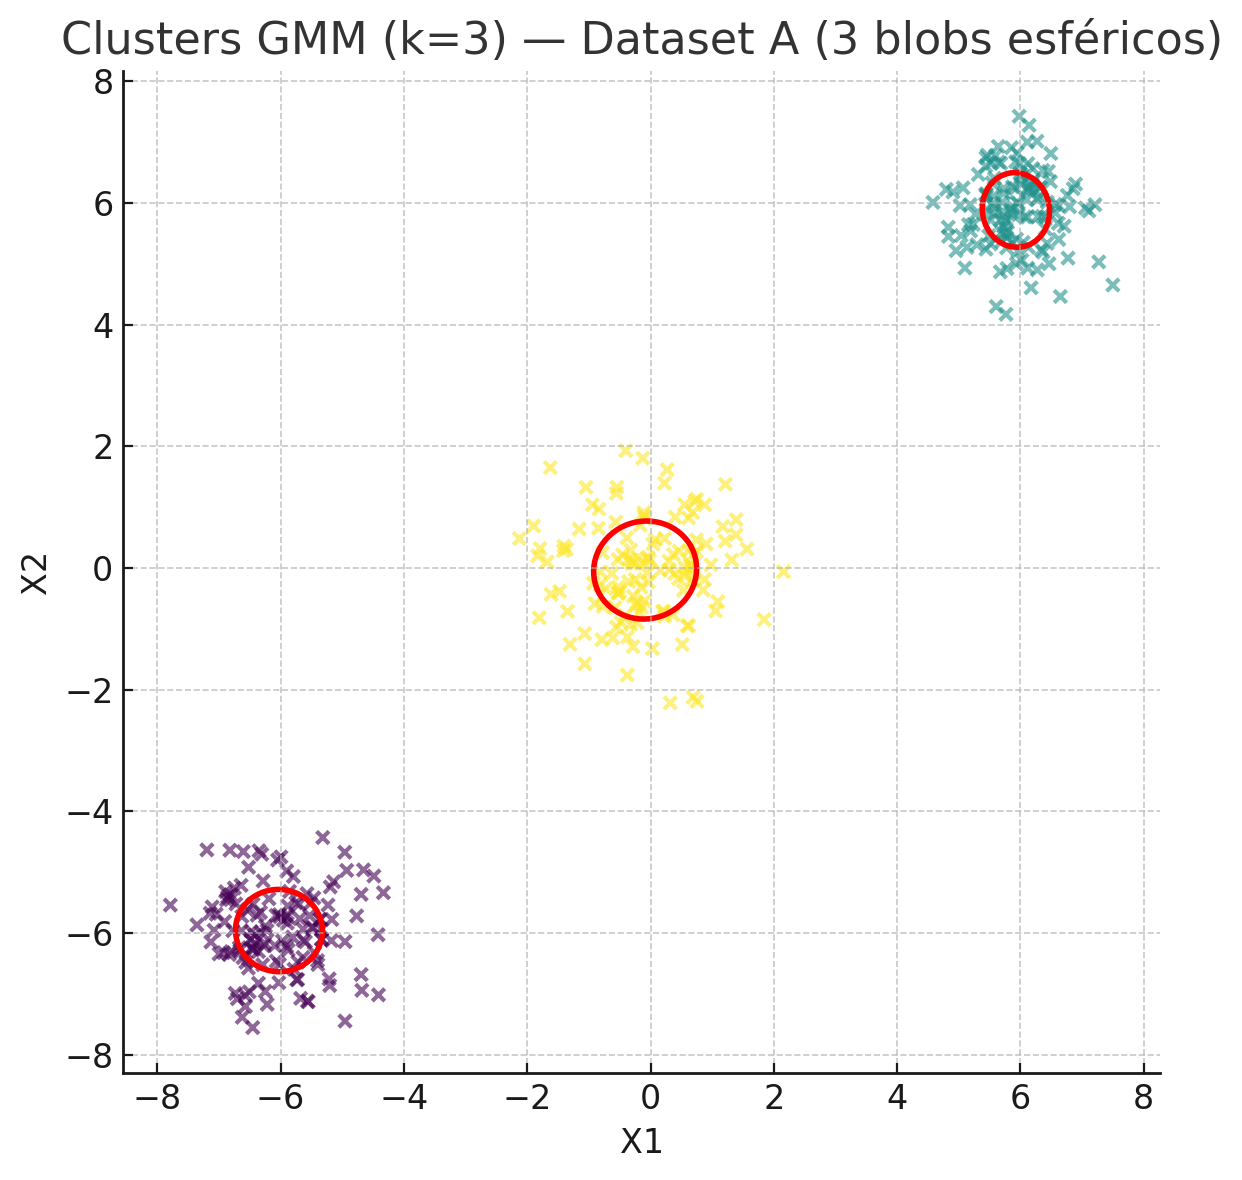

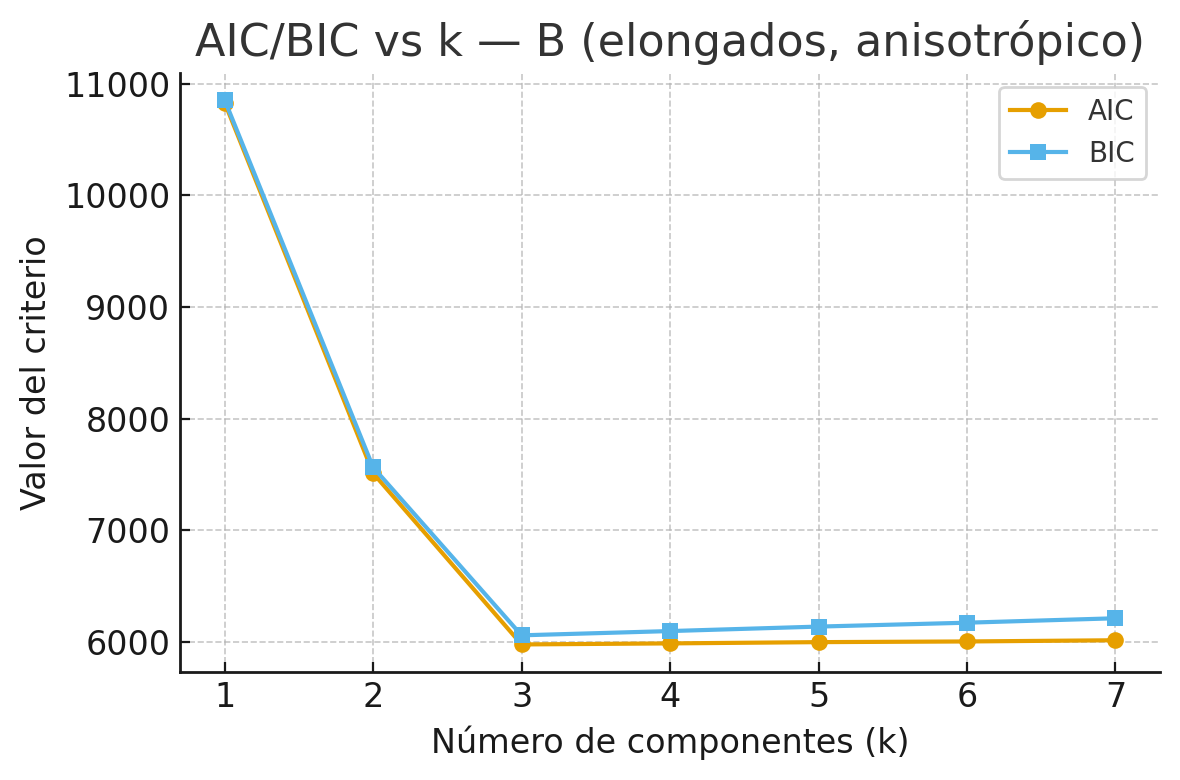

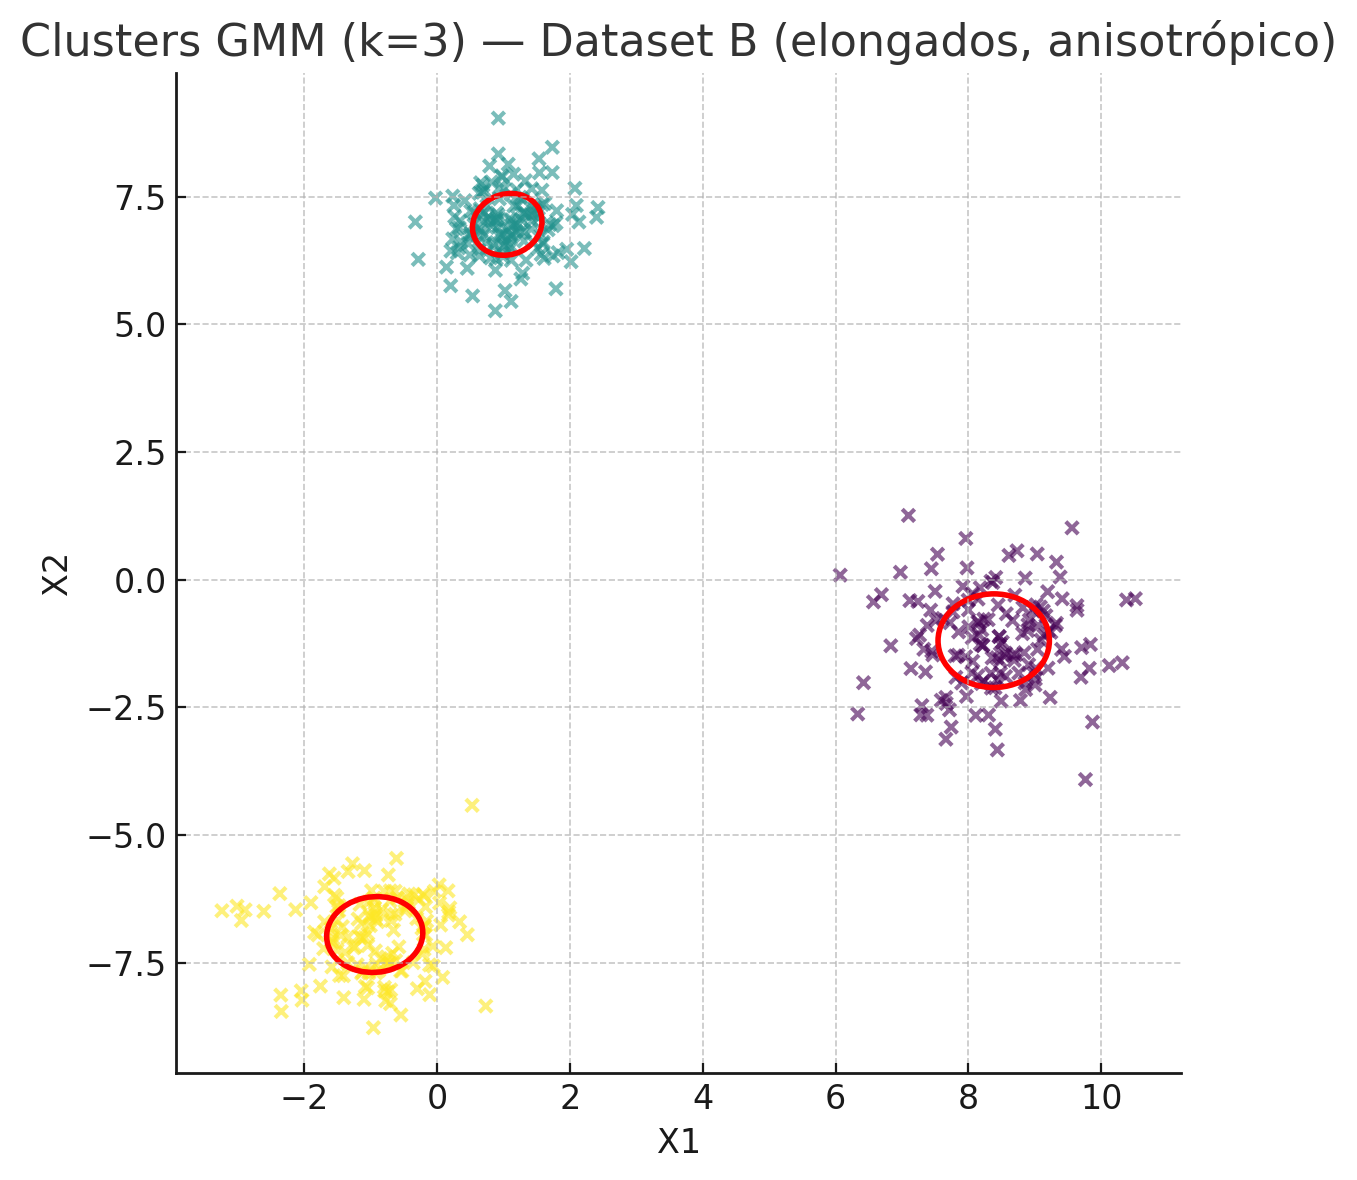

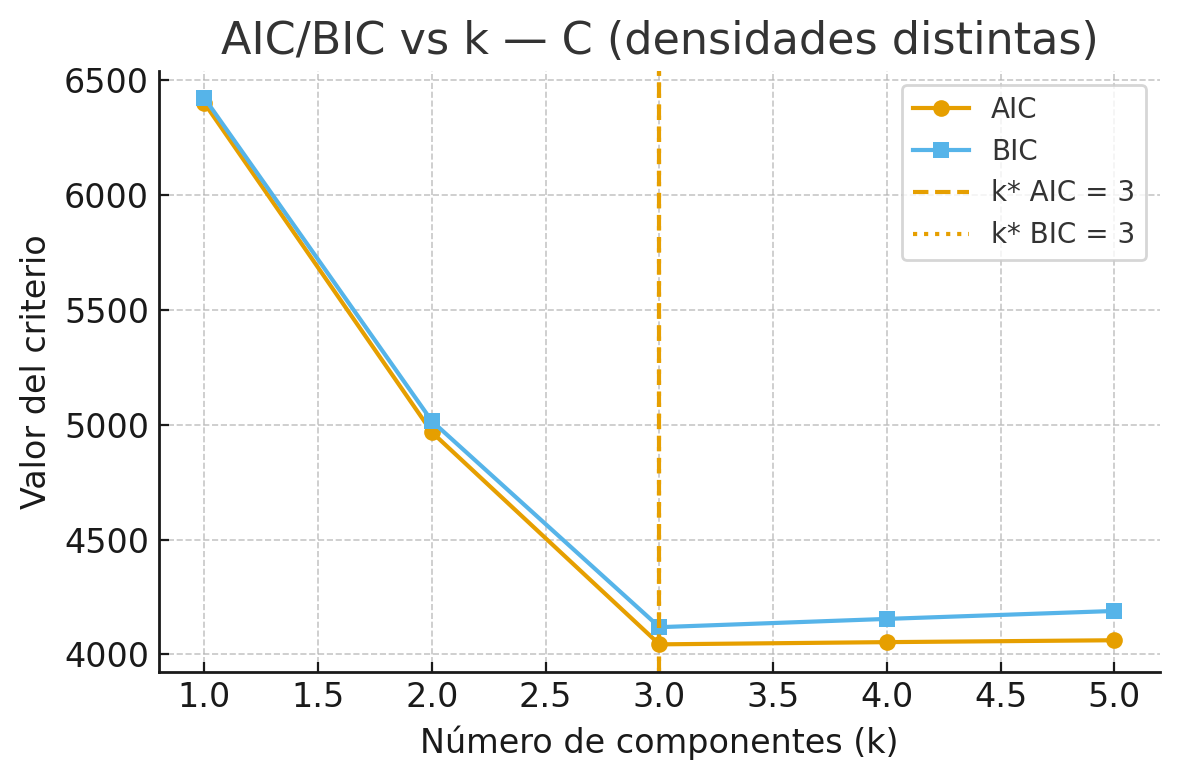

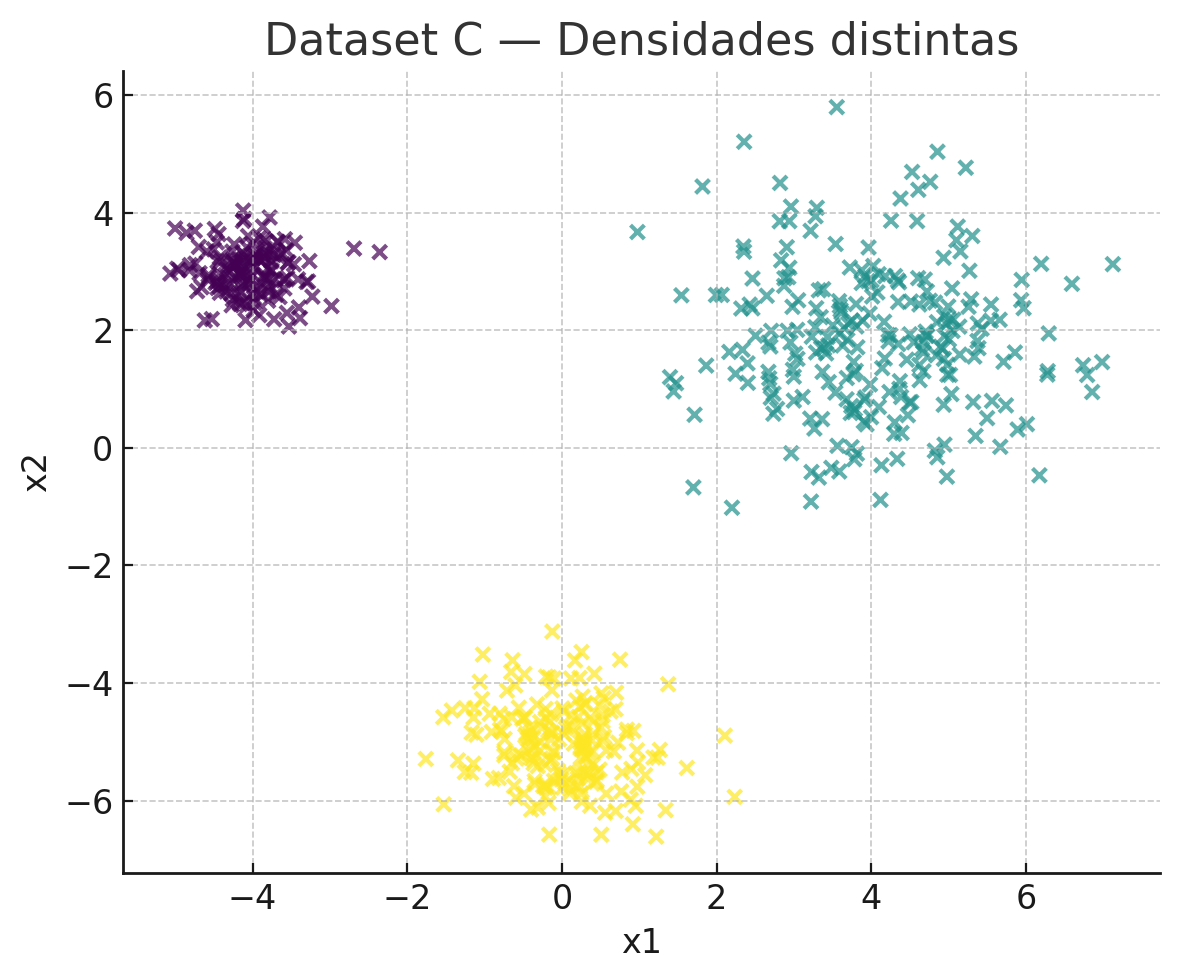

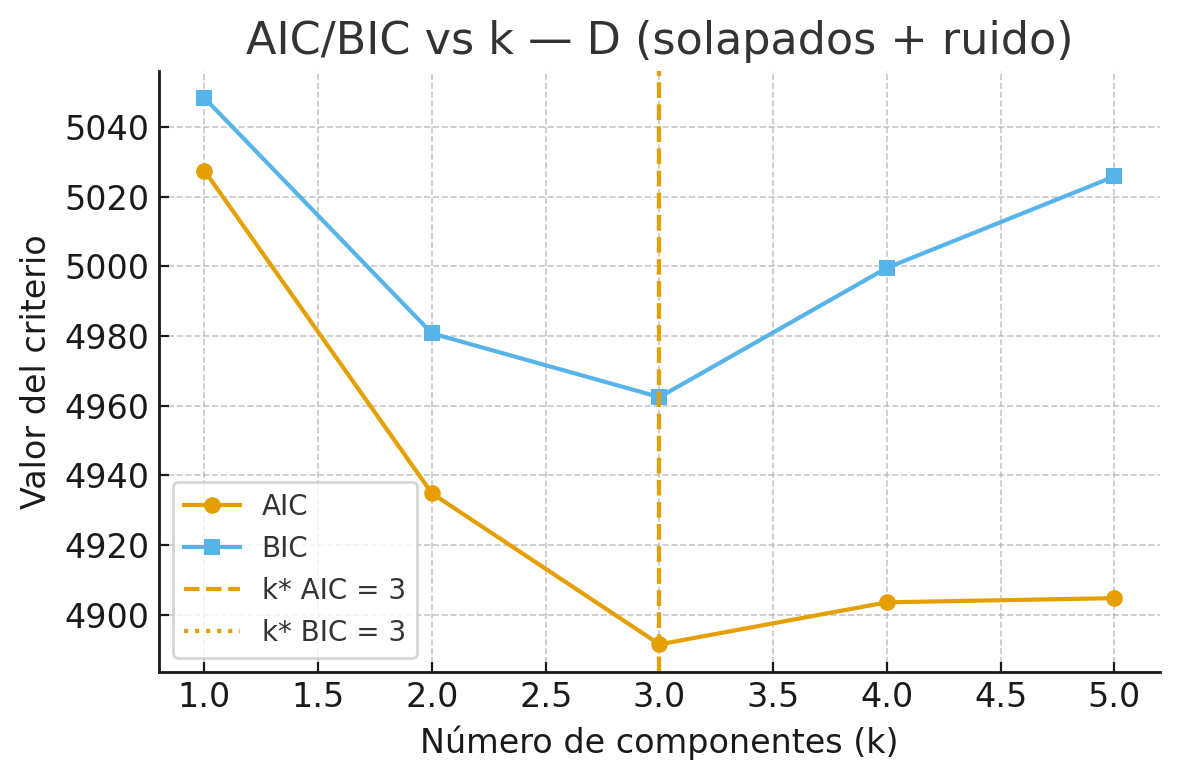

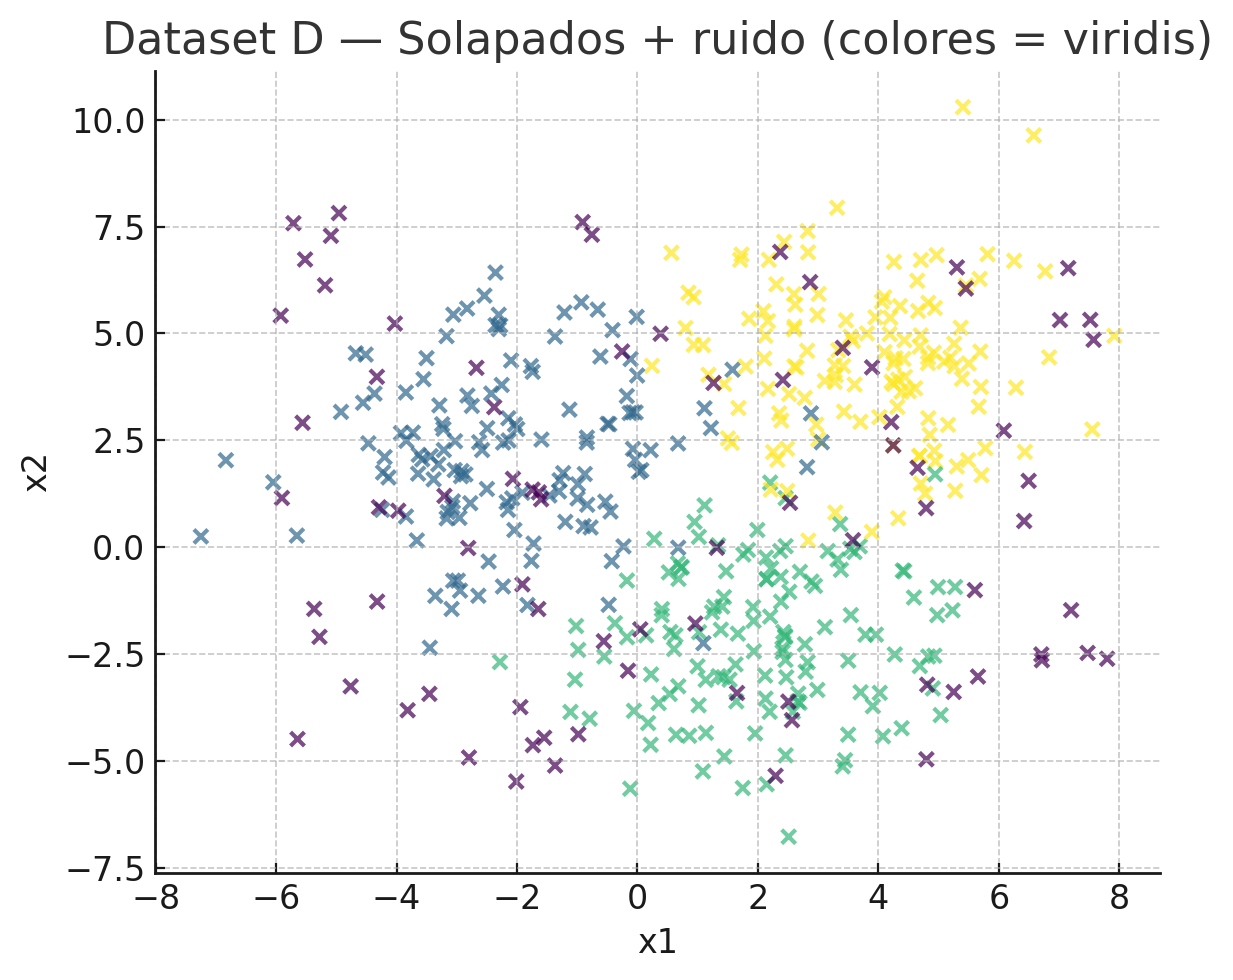

## Caso Extremo de Mezclas Gaussianas

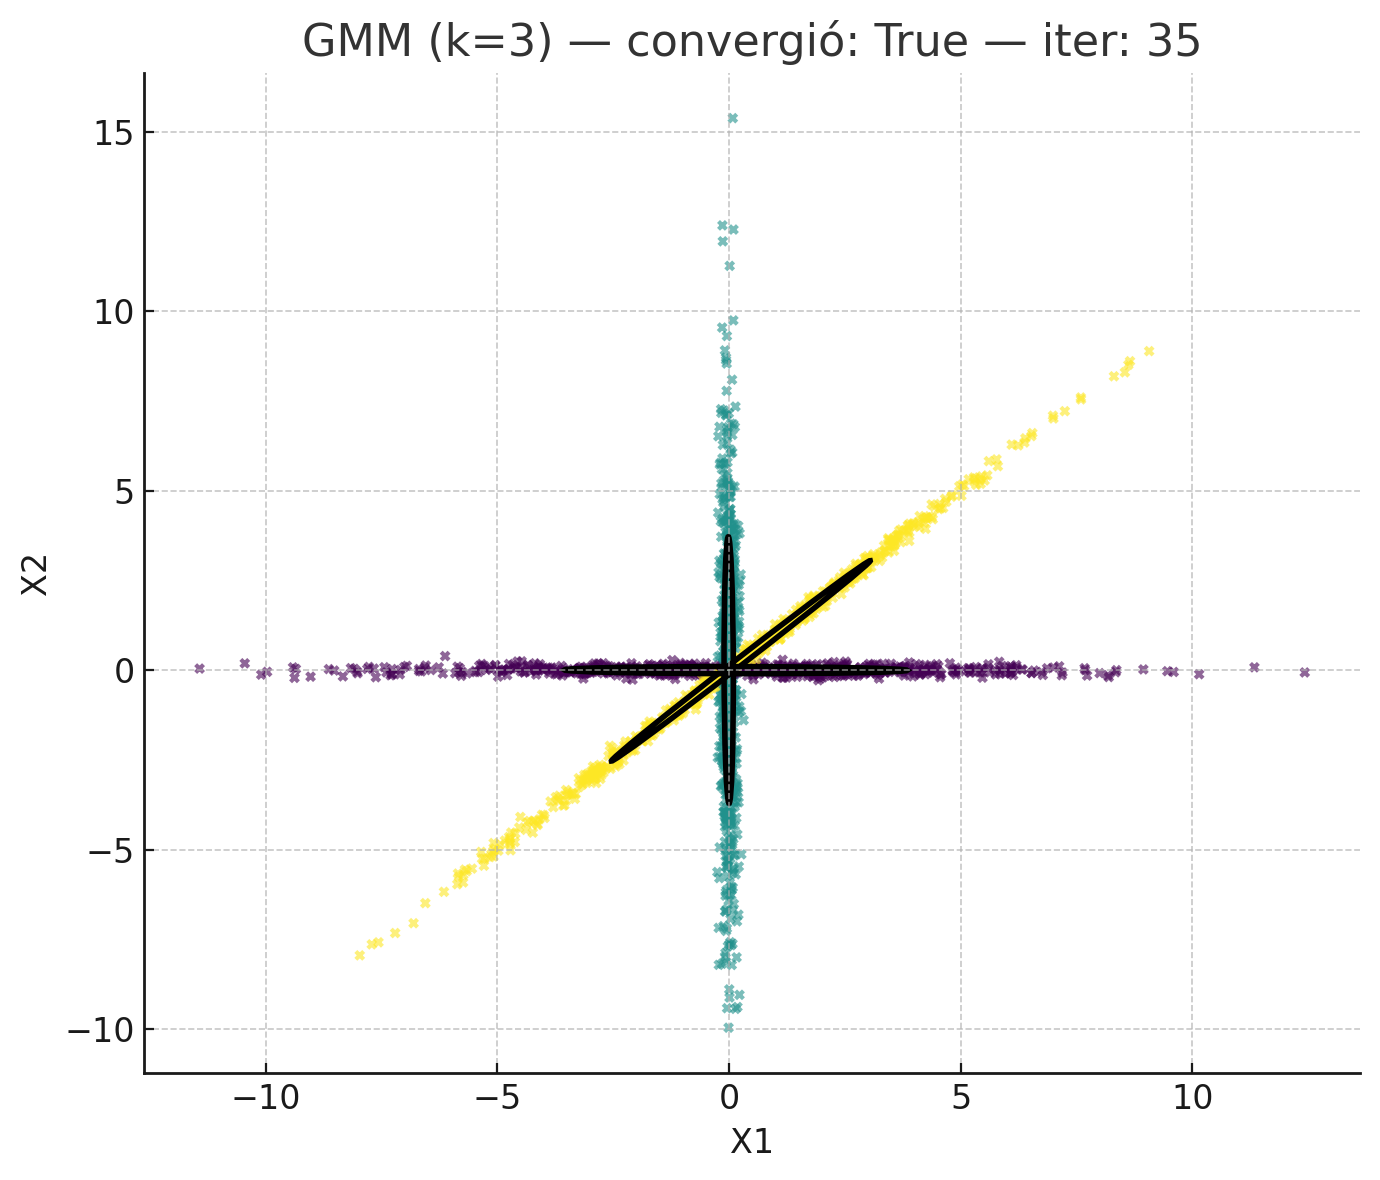